**Цель работы:**

Осуществить предварительную обработку данных csv-файла, выявить и устранить проблемы в этих данных.

# Загрузка набора данных

### Описание предметной области

Вариант №9

Набор данных: visits2.csv

Атрибуты - Данные пользовательских сессий магазина:
1. уникальный идентификатор пользователя
2. страна пользователя
3. устройство пользователя
4. идентификатор рекламного источника, из которого пришел пользователь
5. дата и время начала сессии
6. дата и время окончания сессии
7. время сессии в минутах
8. количество кликов пользователя
9. количество товаров в корзине
10. стоимость покупок
11. возраст пользователя

### 1. Чтение файла (набора данных)

In [2]:
# импорт библиотек, чтение файла с помощью pandas
import pandas as pd

# загрузка CSV-файла
df = pd.read_csv(r'D:\Jupyter_projects\ad_labs\lr2\visits2.csv', sep = ';')

### 2. Обзор данных, проверка данных, изменение данных(при необходимости)

**2.1 Вывод первых 20 строк с помощью метода head.**

In [3]:
# создание копии датафрейма для сравнения использования некоторых методов в дальнейшем
df_clean = df.copy()

In [4]:
# применить метод head (выводит первые n строк датафрейма)
print("Первые строки датафрейма:")
display(df.head(20))

Первые строки датафрейма:


,user_id,region,device,channel,session_start,session_end,time_session,click_count,buy_count,price,age
0,278965908054,United States,iPhone,organic,01.05.2019 4:46,01.05.2019 4:47,1.0,0.0,0.0,0.0,31
1,244878945432,United States,Mac,organic,01.05.2019 16:44,01.05.2019 16:45,1.0,0.0,0.0,0.0,40
2,590706206550,United States,Mac,organic,01.05.2019 14:09,01.05.2019 15:32,83.0,28.0,6.0,14570.0,50
3,326433527971,United States,Android,TipTop,01.05.2019 0:29,01.05.2019 0:54,25.0,8.0,3.0,4411.0,38
4,349773784594,United States,Mac,organic,01.05.2019 3:33,01.05.2019 3:57,24.0,8.0,3.0,4411.0,63
5,90242400005,United States,Android,organic,01.05.2019 9:03,01.05.2019 10:08,65.0,22.0,4.0,11310.0,62
6,43958116050,United States,iPhone,organic,01.05.2019 9:37,01.05.2019 10:00,23.0,8.0,3.0,4411.0,60
7,15174034813,United States,Mac,organic,01.05.2019 13:33,01.05.2019 13:35,2.0,0.0,0.0,0.0,12
8,446013509831,United States,iPhone,organic,01.05.2019 14:44,01.05.2019 15:41,57.0,19.0,4.0,9872.0,52
9,100970711362,United States,Mac,FaceBoom,01.05.2019 6:20,01.05.2019 6:54,34.0,12.0,3.0,6326.0,25


 **2.2 Оценка названий столбцов**

In [7]:
# Вывести на экран названия столбцов с помощью df.columns
display(df.columns)

Index(['user_id ', 'region', 'device', 'channel', 'session_start',
       'session_end', 'time_session', 'click_count', 'buy_count', 'price',
       'age'],
      dtype='object')

Вывод: В конце столбца user_id обнаружен пробел, который следует удалить.

In [45]:
df_clean = df_clean.rename(columns={'user_id ': 'user_id'})

 **2.3 Проверка на наличие пропусков**

In [8]:
# проверить данные на наличие пропусков и устранить их, если они есть (пропуски необходимо либо удалить, либо заменить каким-то значением).
print("Пропущенные значения по столбцам:\n", df.isnull().sum())

Пропущенные значения по столбцам:
 user_id          0
region           1
device           1
channel          0
session_start    0
session_end      0
time_session     0
click_count      0
buy_count        0
price            0
age              0
dtype: int64


Вывод: обнаружено два пропуска, требующих удаления

In [9]:
# применение метода .dropna() для удаления строк таблицы, в которых присутствуют пропуски
df_clean = df_clean.dropna()

In [10]:
print("Пропущенные значения по столбцам:\n", df_clean.isnull().sum())

Пропущенные значения по столбцам:
 user_id          0
region           0
device           0
channel          0
session_start    0
session_end      0
time_session     0
click_count      0
buy_count        0
price            0
age              0
dtype: int64


**2.4 Оценка данных с помощью метода info.**

In [6]:
# выполнит метод info для получение информации о типах значений в ячейках, количестве строк, ненулевых значений и занимаемая память
print("Информация о датафрейме:")
df.info()

Информация о датафрейме:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 954 entries, 0 to 953
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   user_id        954 non-null    int64  
 1   region         953 non-null    object 
 2   device         953 non-null    object 
 3   channel        954 non-null    object 
 4   session_start  954 non-null    object 
 5   session_end    954 non-null    object 
 6   time_session   954 non-null    float64
 7   click_count    954 non-null    float64
 8   buy_count      954 non-null    float64
 9   price          954 non-null    float64
 10  age            954 non-null    int64  
dtypes: float64(4), int64(2), object(5)
memory usage: 82.1+ KB


Вывод: Несоответствие типов данных в столбцах начала и конца сессии, а так же число кликов и количества купленных товаров

In [13]:
# 1. Приведение числовых значений, типы которых не соответствуют логике
df_clean['click_count'] = df_clean['click_count'].astype(int)
df_clean['buy_count'] = df_clean['buy_count'].astype(int)

# 2. Преобразуем временные поля в datetime
df_clean['session_start'] = pd.to_datetime(df_clean['session_start'], dayfirst=True, errors='coerce')
df_clean['session_end'] = pd.to_datetime(df_clean['session_end'], dayfirst=True, errors='coerce')

# После преобразования могли появиться NaN — удаляем их тоже
df_clean.dropna(subset=['session_start', 'session_end'], inplace=True)

In [62]:
# выполнит метод info для получение информации о типах значений в ячейках, количестве строк, ненулевых значений и занимаемая память
print("Информация о датафрейме:")
df_clean.info()

Информация о датафрейме:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 849 entries, 0 to 848
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         849 non-null    int64         
 1   region          849 non-null    object        
 2   device          849 non-null    object        
 3   channel         849 non-null    object        
 4   session_start   849 non-null    datetime64[ns]
 5   session_end     849 non-null    datetime64[ns]
 6   time_session    849 non-null    float64       
 7   click_count     849 non-null    int64         
 8   buy_count       849 non-null    int64         
 9   price           849 non-null    float64       
 10  age             849 non-null    int64         
 11  price_category  849 non-null    category      
dtypes: category(1), datetime64[ns](2), float64(2), int64(4), object(3)
memory usage: 74.0+ KB


In [15]:
df_clean.head(10)

,user_id,region,device,channel,session_start,session_end,time_session,click_count,buy_count,price,age
0,278965908054,United States,iPhone,organic,2019-05-01 04:46:00,2019-05-01 04:47:00,1.0,0,0,0.0,31
1,244878945432,United States,Mac,organic,2019-05-01 16:44:00,2019-05-01 16:45:00,1.0,0,0,0.0,40
2,590706206550,United States,Mac,organic,2019-05-01 14:09:00,2019-05-01 15:32:00,83.0,28,6,14570.0,50
3,326433527971,United States,Android,TipTop,2019-05-01 00:29:00,2019-05-01 00:54:00,25.0,8,3,4411.0,38
4,349773784594,United States,Mac,organic,2019-05-01 03:33:00,2019-05-01 03:57:00,24.0,8,3,4411.0,63
5,90242400005,United States,Android,organic,2019-05-01 09:03:00,2019-05-01 10:08:00,65.0,22,4,11310.0,62
6,43958116050,United States,iPhone,organic,2019-05-01 09:37:00,2019-05-01 10:00:00,23.0,8,3,4411.0,60
7,15174034813,United States,Mac,organic,2019-05-01 13:33:00,2019-05-01 13:35:00,2.0,0,0,0.0,12
8,446013509831,United States,iPhone,organic,2019-05-01 14:44:00,2019-05-01 15:41:00,57.0,19,4,9872.0,52
9,100970711362,United States,Mac,FaceBoom,2019-05-01 06:20:00,2019-05-01 06:54:00,34.0,12,3,6326.0,25


 **2.5 Проверка явных дубликатов**

In [11]:
# находим сумму явных дубликатов
print(df_clean.duplicated().sum())

0


Вывод: явные дубликаты обнаружены не были, так что оставляем без измененеий

 **2.6 Проверка неявных дубликатов**

In [17]:
# первый шаг проверки на неявные дубликаты - выделение всех уникальных значений в колонках
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':  # только текстовые столбцы
        # приводим строки к нижнему регистру и убираем пробелы
        cleaned = df_clean[col]
        
        # получаем уникальные значения
        unique_vals = cleaned.unique()
        
        print(f"\nСтолбец '{col}' - уникальные значения:")
        print(unique_vals)


Столбец 'region' - уникальные значения:
['United States' 'Russia' 'USA']

Столбец 'device' - уникальные значения:
['iPhone' 'Mac' 'Android' 'PC' 'MAC' 'IPHONE']

Столбец 'channel' - уникальные значения:
['organic' 'TipTop' 'FaceBoom' 'MediaTornado']


Вывод: обнаружены явные дубликаты в столбцах, представляющие из себя запись одних и теж же значений в разной форме

In [18]:
# удаление дубликатов, если они есть
df_clean['region'] = df_clean['region'].replace('United States', 'USA')
df_clean['device'] = df_clean['device'].replace('IPHONE', 'iPhone')
df_clean['device'] = df_clean['device'].replace('MAC', 'Mac')

**2.7 Оценка данных с помощью метода describe.**

In [19]:
# оцените числовые столбцы с помощью describe
print("Статистическое описание числовых признаков:")
display(df.describe())

Статистическое описание числовых признаков:


,user_id,session_start,session_end,time_session,click_count,buy_count,price,age
count,9.540000e+02,954,954,954.000000,954.000000,954.000000,954.000000,954.000000
mean,4.951807e+11,2019-05-02 08:12:14.150943232,2019-05-02 08:41:17.924528384,29.062893,9.830189,2.527254,5341.559748,39.810273
min,2.346325e+09,2019-05-01 00:06:00,2019-05-01 00:19:00,0.000000,0.000000,0.000000,0.000000,10.000000
25%,2.295122e+11,2019-05-01 20:21:15,2019-05-01 20:48:30,9.000000,3.000000,2.000000,2301.000000,29.000000
50%,4.984267e+11,2019-05-02 08:09:00,2019-05-02 08:35:00,21.000000,7.000000,2.000000,3739.000000,39.000000
75%,7.525332e+11,2019-05-02 18:43:15,2019-05-02 18:57:45,42.000000,14.000000,3.000000,7284.000000,50.000000
max,9.985130e+11,2019-05-04 23:46:00,2019-05-04 23:52:00,262.000000,88.000000,15.000000,56546.000000,71.000000
std,2.899488e+11,NaN,NaN,27.134816,9.209039,1.602003,5060.247685,13.038029


In [20]:
# удаляем строки с нулями в ключевых числовых столбцах, которые можно посчитать за аномалии
df_clean = df_clean[(df_clean['time_session'] > 0) &
        (df_clean['click_count'] > 0) &
        (df_clean['buy_count'] > 0) &
        (df_clean['price'] > 0)]

#### Выводы по анализу статического описания
В данном описании представлены такие характеристики, как 
**count(количество)**, 
**mean(среднее арифметическое)**, 
**std(стандартное отклонение) - показывает разброс значений вокруг среднего**
**min и max - минимальное и максимальное значения соответственно**
**25%(первый квартиль) - 25% значений меньше или равны этому числу**
**50%(медиана) - центральное значение, т.е 50% значений больше и меньше данного**
**75%(третий квартиль) - 75% значений меньше или равны этому числу**

В исследуемом наборе содержится **954 записи**, каждая из которых представляет отдельную пользовательскую сессию.

Столбцы `session_start` и `session_end` имеют строковый тип, что требует преобразования к формату даты и времени для корректного анализа длительности сессий. Поле `user_id` числовое, но используется лишь как идентификатор — его статистика неинформативна.

По описательной статистике выведено следующее:

* **Продолжительность сессии (`time_session`)**: среднее значение около 29 минут при медиане 21 минута. Распределение имеет выраженную правостороннюю асимметрию — большинство сессий короткие, но встречаются и значительно более длительные (до 262 минут). Нулевые значения указывают на случаи мгновенных, что скорее воспринимается как аномалия.

* **Количество кликов (`click_count`)**: среднее около 9,8 кликов при медиане 7. Распределение также скошено вправо — большинство пользователей совершают немного действий, однако есть отдельные сессии с крайне высоким числом кликов (до 88).

* **Количество покупок (`buy_count`)**: среднее 2,5, медиана 2. Значительная часть пользователей ограничивается одной-двумя покупками, а максимум (15) показывает наличие активных покупателей.

* **Стоимость покупок (`price`)**: средняя сумма покупки ≈ 5340 при медиане 3739. Большой разрыв между средним и медианой, а также высокий максимум (56 546) говорят о сильной положительной асимметрии и наличии выбросов — редких сессий с очень высокими чеками. Четверть пользователей тратят менее 2300, три четверти — менее 7300. Нулевые значения отражают отсутствие покупок. Дорогие покупки не стоит воспринимать как аномалии

* **Возраст (`age`)**: значения варьируются от 10 до 71 года, средний возраст ≈ 40 лет. Распределение достаточно равномерное, без выраженных выбросов, основная доля пользователей — взрослые от 30 до 50 лет.

Таким образом, данные характеризуются **сильной неоднородностью и наличием выбросов** в признаках, связанных с активностью и стоимостью покупок. Это типично для пользовательских данных магазина.

В целом структура набора данных позволяет проводить дальнейший исследовательский анализ — строить распределения, диаграммы рассеяния и корреляционные зависимости для выявления закономерностей между активностью пользователей, временем сессий, количеством кликов и величиной покупок.

In [22]:
df_clean.reset_index(drop=True, inplace=True)

### 3. Общие задания лабораторной работы

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

#### Матрица диаграмм рассеяния

Формулировка задания 2: Построить точечную диаграмму (матрицу диаграмм рассеяния) для всех признаков. Выполнить анализ полученной диаграммы, отвечая на вопрос показывает ли она в среднем определенную зависимость между переменными. Изучите параметры и опишите взаимосвязи. Если параметров слишком много – может потребоваться создать несколько графиков. Минимум один график (диаграмму рассеивания) сделать по категориям (Например, зависимость зарплаты и возраста по каждой должности. На таком графике различные должности должны быть показаны разными цветами).

Функция pairplot() из библиотеки Seaborn используется для визуализации попарных зависимостей между числовыми признаками.
На диагонали матрицы отображаются гистограммы распределений, а вне диагонали — диаграммы рассеяния, показывающие взаимосвязи между переменными.

Параметры:

hue='device' — точки окрашиваются в разные цвета в зависимости от используемого устройства;

diag_kind='hist' — тип диаграммы на диагонали (гистограмма);

plot_kws={'alpha': 0.6} — полупрозрачность точек для лучшей читаемости при наложении;

palette='Set2' — приятная цветовая палитра для категорий;

plt.suptitle() и plt.tight_layout() — добавляют общий заголовок и корректируют отступы между элементами графика.

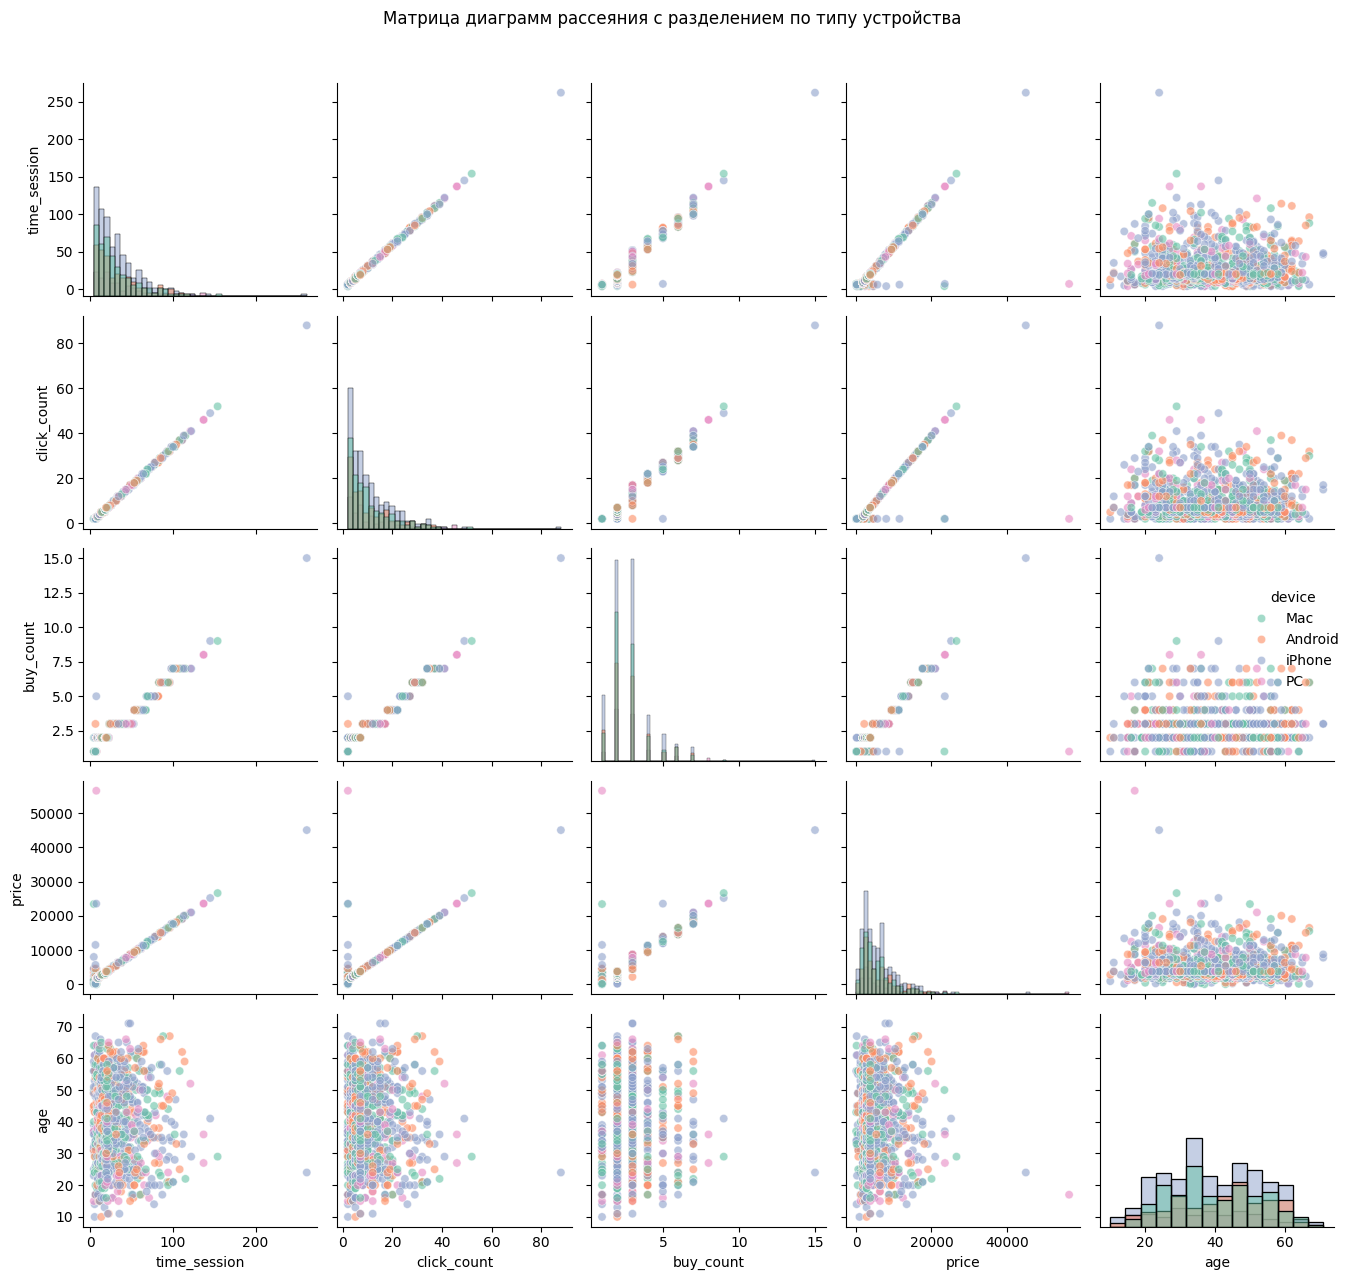

In [26]:
# Числовые признаки для анализа
numeric_cols = ['time_session', 'click_count', 'buy_count', 'price', 'age']

# Матрица диаграмм рассеяния
sns.pairplot(df_clean[numeric_cols + ['device']],
             hue='device',                # категориальный признак для окрашивания  
             diag_kind='hist',            # на диагонали — гистограммы распределения
             plot_kws={'alpha': 0.6},     # прозрачность точек
             palette='Set2')

plt.suptitle('Матрица диаграмм рассеяния с разделением по типу устройства', y=1.02)
plt.tight_layout()
plt.show()


**Вывод:**

Для анализа попарных зависимостей между числовыми признаками (time_session, click_count, buy_count, price, age) была построена матрица диаграмм рассеяния с разделением по типу устройства (device).

На диагонали отображены гистограммы распределений признаков. Видно, что продолжительность сессии, количество кликов, число покупок и стоимость имеют правостороннее распределение: большинство значений сосредоточено в нижних диапазонах, но присутствуют редкие случаи с большими величинами. Распределение возрастов пользователей более равномерное с небольшим смещением к группе 30–50 лет.

Вне диагонали наблюдаются выраженные положительные зависимости между признаками, связанными с активностью и покупками. Чем больше длительность сессии, тем выше количество кликов и покупок, а также сумма трат. Между количеством кликов и количеством покупок наблюдается почти линейная зависимость, что отражает прямое влияние вовлечённости пользователя на конверсию.

Возраст не показывает заметных корреляций с остальными переменными.

Цветовая сегментация по устройствам показывает, что пользователи Android, iPhone, Mac и PC имеют сходные тенденции, однако владельцы Mac и iPhone в среднем совершают чуть более длительные и дорогие сессии.

Таким образом, диаграммы рассеяния демонстрируют, что ключевыми факторами, влияющими на стоимость покупок, являются активность пользователя и длительность его пребывания в приложении, а не возраст или тип устройства.

### Матрица диаграмм рассеяния (пример без цвета категорий)

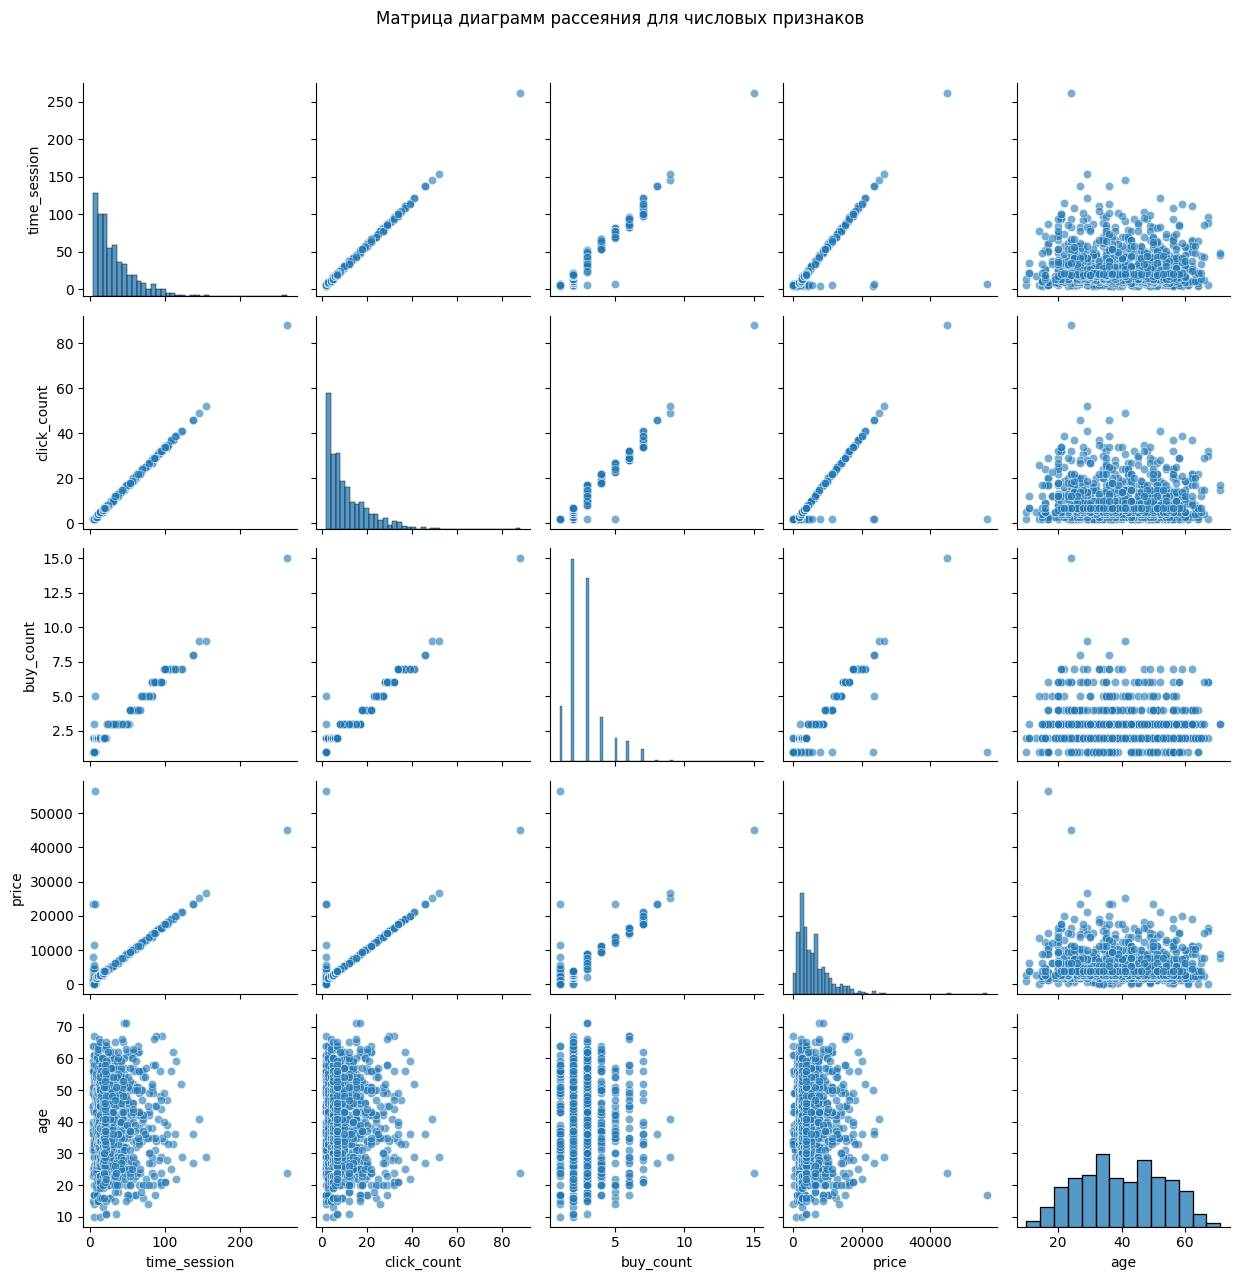

In [27]:
# Построение матрицы рассеяния без категориальной окраски
sns.pairplot(df_clean[numeric_cols],
             diag_kind='hist',
             plot_kws={'alpha': 0.6})

plt.suptitle('Матрица диаграмм рассеяния для числовых признаков', y=1.02)
plt.tight_layout()
plt.show()

#### Гистограммы для каждого числового признака

Формулировка задания 3. Постройте гистограммы для каждого числового признака, подберите оптимальное количество bins, сделайте выводы по полученными гистограммам.

Для построения гистограмм была создана сетка графиков размером 2×3 с помощью функции plt.subplots() из библиотеки Matplotlib. Такой приём позволяет разместить несколько распределений на одной фигуре, обеспечивая компактное и удобное сравнение числовых признаков.
Параметр figsize=(16, 10) задаёт размеры всей визуализации, а функция fig.suptitle() формирует общий заголовок, отражающий цель анализа — изучение распределений числовых характеристик пользователей.

Для каждого числового признака (time_session, click_count, buy_count, price, age) построена отдельная гистограмма с помощью метода hist().
Гистограмма отображает распределение значений признака — частоту появления наблюдений в различных диапазонах. Каждое значение попадает в один из интервалов (bins), а высота столбца соответствует количеству пользователей, у которых значение признака попадает в данный диапазон.

В параметрах функции hist() были использованы следующие настройки:

bins — количество интервалов, на которые делится диапазон значений. Подбор оптимального числа интервалов обеспечивает наглядность распределения: слишком малое значение скрывает детали, а слишком большое создаёт излишний шум;

color — цвет столбцов, подобран индивидуально для каждого признака для лучшей визуальной дифференциации;

edgecolor='black' — добавляет чёрные контуры столбцов, делая границы гистограммы более чёткими;

alpha=0.7 — регулирует прозрачность, смягчая цветовую насыщенность и улучшая восприятие графика.

Для каждого подграфика заданы подписи осей (set_xlabel, set_ylabel) и заголовок (set_title), которые поясняют, какой признак визуализирован.
Команда grid(axis='y', alpha=0.3) добавляет лёгкую горизонтальную сетку, что помогает визуально оценивать частоты наблюдений.

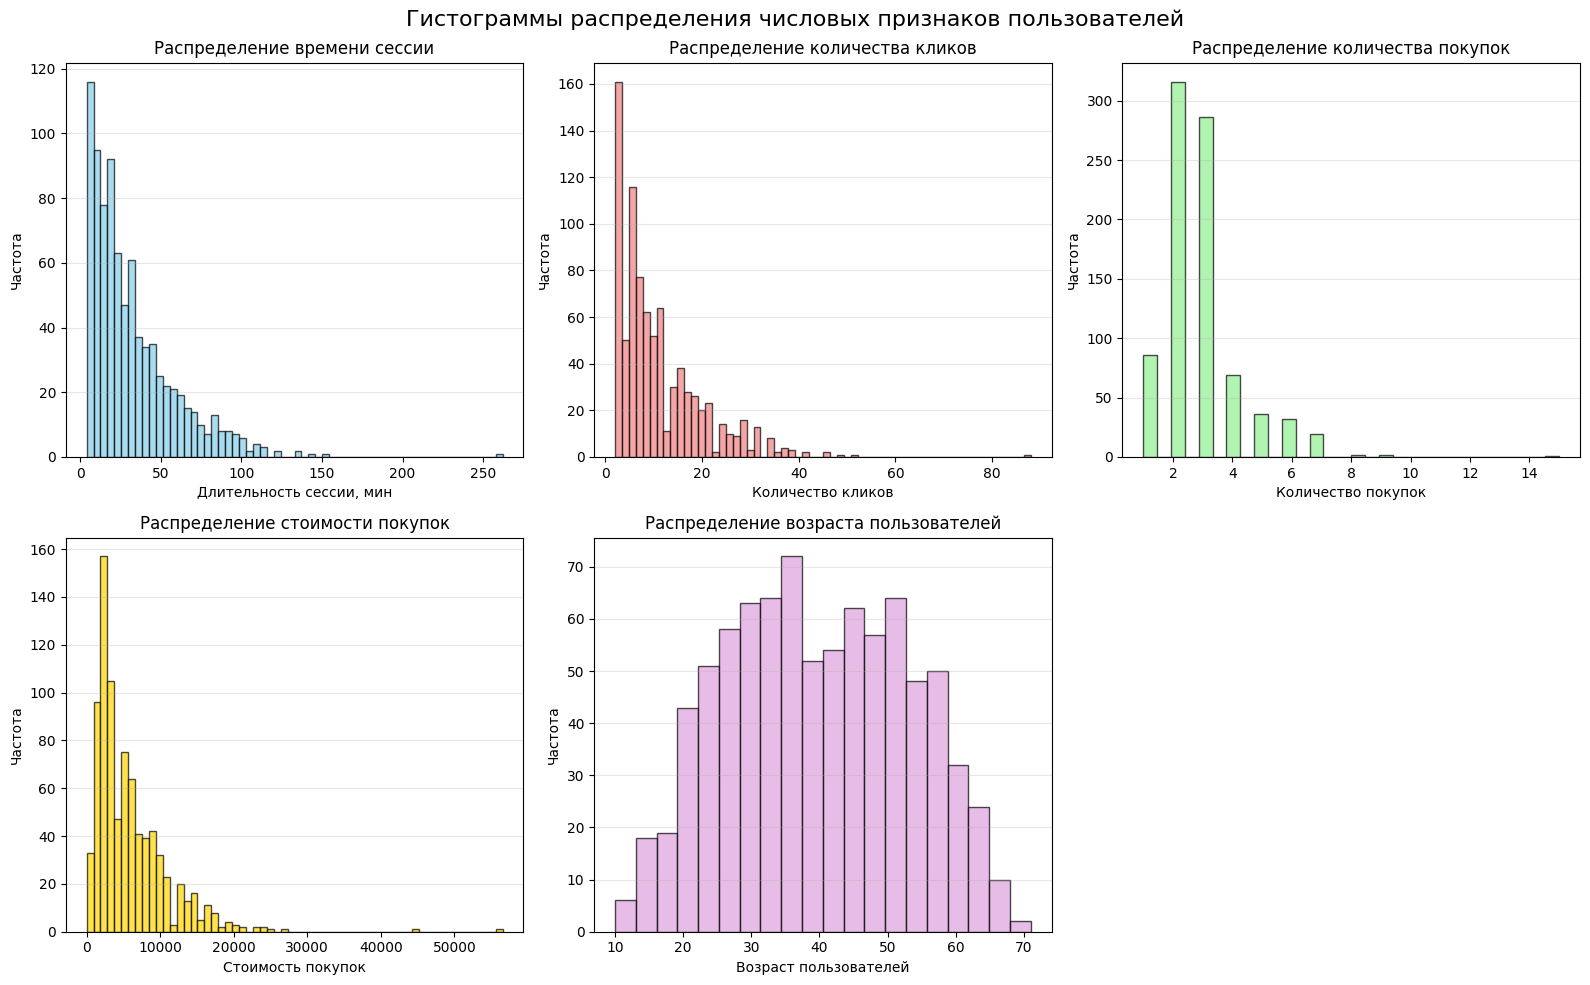

In [28]:
# Создание сетки под 5 гистограмм (2 строки, 3 столбца)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Гистограммы распределения числовых признаков пользователей', fontsize=16)

# --- Гистограмма 1: Время сессии ---
axes[0, 0].hist(df_clean['time_session'], bins=60, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Длительность сессии, мин')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].set_title('Распределение времени сессии')
axes[0, 0].grid(axis='y', alpha=0.3)

# --- Гистограмма 2: Количество кликов ---
axes[0, 1].hist(df_clean['click_count'], bins=60, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Количество кликов')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].set_title('Распределение количества кликов')
axes[0, 1].grid(axis='y', alpha=0.3)

# --- Гистограмма 3: Количество покупок ---
axes[0, 2].hist(df_clean['buy_count'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 2].set_xlabel('Количество покупок')
axes[0, 2].set_ylabel('Частота')
axes[0, 2].set_title('Распределение количества покупок')
axes[0, 2].grid(axis='y', alpha=0.3)

# --- Гистограмма 4: Стоимость покупок ---
axes[1, 0].hist(df_clean['price'], bins=60, color='gold', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Стоимость покупок')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].set_title('Распределение стоимости покупок')
axes[1, 0].grid(axis='y', alpha=0.3)

# --- Гистограмма 5: Возраст ---
axes[1, 1].hist(df_clean['age'], bins=20, color='plum', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Возраст пользователей')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].set_title('Распределение возраста пользователей')
axes[1, 1].grid(axis='y', alpha=0.3)

# Удалим пустое место последнего графика (2,2)
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

**Вывод:**
Анализ представленных гистограмм позволяет выявить ключевые поведенческие паттерны пользователей интернет-магазина. Распределения всех рассмотренных показателей демонстрируют ярко выраженную правостороннюю асимметрию (положительную скошенность). Это означает, что большинство пользовательских сессий характеризуются очень низкими значениями, в то время как сессии с высокими показателями встречаются крайне редко, формируя "длинный хвост" в правой части графиков.

1. Распределение времени сессии
Наблюдения: Распределение резко спадающее. Подавляющее большинство сессий длятся всего несколько минут (сосредоточены в области 0-10 минут). Количество сессий экспоненциально уменьшается с ростом их длительности. Сессии, длящиеся больше часа, являются исключительными случаями.

Итог: Пользователи в основном быстро покидают сайт. Это может указывать на "окнобраузинг" (ознакомительный просмотр), быстрые целевые действия (например, поиск конкретной информации) или высокий уровень оттока (bounce rate). Длинные сессии, вероятно, соответствуют пользователям, активно изучающим ассортимент или совершающим сложную покупку.

2. Распределение количества кликов
Наблюдения: Аналогично времени сессии, распределение сильно скошено вправо. Большинство пользователей совершают всего несколько кликов за сессию (вероятно, 1-10 кликов). Сессии с десятками кликов являются редкими.

Итог: Низкое количество кликов подтверждает гипотезу о коротких сессиях. Пользователи либо быстро находят нужное, либо так же быстро теряют интерес. Активные сессии с большим количеством кликов могут соответствовать вдумчивому шопингу или использованию фильтров и поиска.

3. Распределение количества покупок (buy_count)
Наблюдения: Совершение 3, 4 и более покупок за одну сессию — маловероятное событие.

Итог: Данный график наглядно показывает коэффициент конверсии (соотношение сессий с покупками и всех сессий). Он явно невысок. Это ключевая метрика для любого интернет-магазина, и ее необходимо повышать.

4. Распределение стоимости покупок (price)
Наблюдения: Распределение также правостороннее. Основная масса ненулевых покупок (исключая столбец на 0) сосредоточена в области относительно низких стоимостей. Совершение крупных покупок на десятки тысяч является аномалией.

Итог: Вместе с предыдущим графиком это показывает, что не только покупки совершаются в малом проценте сессий, но и их средний чек, за исключением редких выбросов, является умеренным.

5. Распределение возраста пользователей (age)
Наблюдения: В отличие от других метрик, распределение возраста приближено к нормальному с легким смещением. Ядро аудитории сосредоточено в возрастной группе примерно от 30 до 60 лет. Количество очень молодых (до 20) и пожилых (после 60) пользователей постепенно снижается.

Итог: Магазин успешно привлекает экономически активное население. Это ценная аудитория с высоким покупательским потенциалом. Понимание возрастного портрета помогает таргетировать рекламу и адаптировать интерфейс.

#### Анализ корреляций

Формулировка задания:

Исследовать взаимосвязь между переменными с помощью оценки коэффициента корреляции и ковариации. Построить heatmap (тепловую карту корреляции). Выполнить интерпретацию результатов корреляции и ковариации, отвечая на вопросы о наличии (отсутствии) линейной взаимосвязи между переменными. Понимать, что такое корреляция и ковариация.

Описание процесса:

Из очищенного датафрейма df_clean выбираются только числовые столбцы для анализа.

Метод .corr() библиотеки pandas вычисляет матрицу корреляций между всеми выбранными числовыми признаками. По умолчанию используется коэффициент Пирсона.

На выходе получается квадратная таблица размера n×n, где n — количество числовых столбцов.

Элементы диагонали всегда равны 1.0 (корреляция признака с самим собой), а все остальные элементы — значения корреляции для каждой пары признаков, в диапазоне [-1, 1].

In [29]:
# Выбираем только числовые столбцы
numeric_cols = df_clean.select_dtypes(include='number').columns

# Вычисляем матрицу корреляций
correlation_matrix = df_clean[numeric_cols].corr()

#### Построение тепловой карты корреляций

Для наглядного анализа связей между числовыми признаками создаётся график с помощью Matplotlib размером 10×8 дюймов. В нём строится тепловая карта, которая позволяет визуально оценить силу и направление корреляций.

Ключевые параметры команды sns.heatmap:

* correlation_matrix — входная матрица корреляций.

* annot=True — отображение числовых значений коэффициентов корреляции в каждой ячейке.

* fmt='.3f' — формат чисел: три знака после запятой.

* cmap='coolwarm' — цветовая шкала: положительные корреляции окрашены в тёплые (красные), отрицательные — в холодные (синие) оттенки.

* center=0 — центрирование цветовой шкалы по нулю для визуальной симметрии положительных и отрицательных значений.

* square=True — ячейки квадратные, чтобы сохранить аккуратную сетку.

* linewidths=1 — толщина разделительных линий между ячейками.

* cbar_kws={"shrink": 0.8} — уменьшение размера полосы цветовой шкалы до 80% для лучшего размещения.

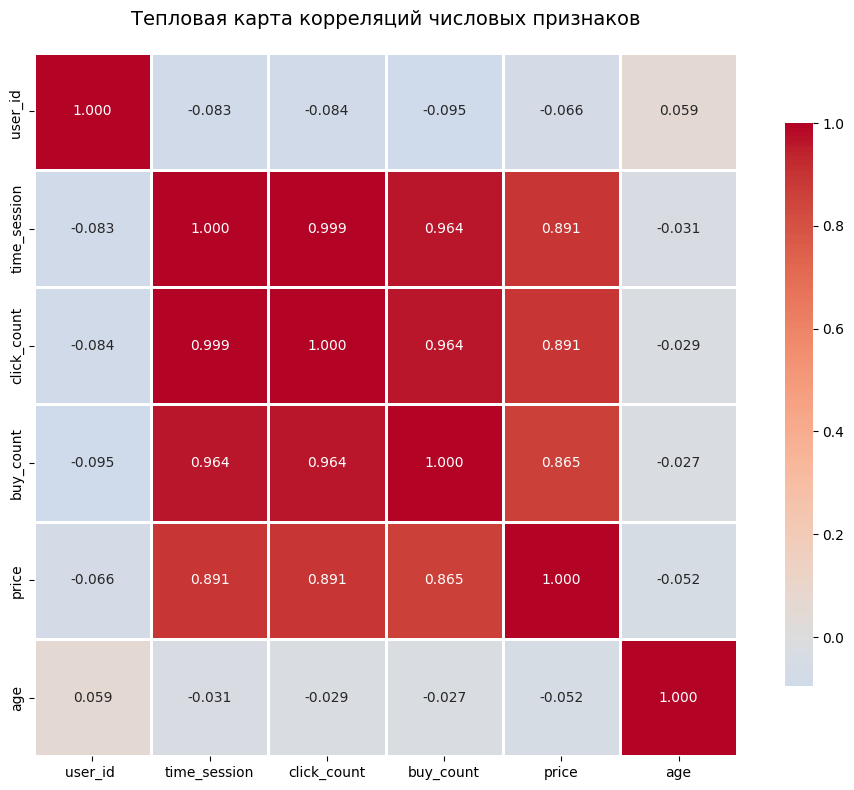

In [30]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,
            annot=True,
            fmt='.3f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8})
plt.title('Тепловая карта корреляций числовых признаков', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

**Вывод:**

Анализ матрицы корреляций выявил наличие исключительно сильных взаимосвязей между ключевыми поведенческими метриками сессии, а также подтвердил независимость демографического признака от поведения на сайте.

1. Выявление сильных положительных корреляций
Наблюдается очень сильная положительная связь между тремя основными метриками активности пользователя во время сессии:

time_session и click_count: Коэффициент корреляции ~0.999 (практически 1.0).

time_session и buy_count: Коэффициент корреляции ~0.964.

click_count и buy_count: Коэффициент корреляции ~0.964.

Интерпретация:
Эта закономерность абсолютно логична и ожидаема:

Чем дольше пользователь находится на сайте, тем больше действий он совершает (кликов). Это прямое следствие.

Чем дольше сессия и чем больше в ней кликов, тем выше вероятность совершения покупки и тем больше количество товаров в корзине. Это ключевой инсайт для бизнеса: чтобы увеличить продажи, необходимо удерживать пользователей на сайте и стимулировать их к активному взаимодействию с контентом (просмотру большего количества товаров, использованию фильтров и т.д.).

2. Умеренная связь с финансовым результатом
Обнаружена сильная положительная корреляция между поведенческими метриками и стоимостью покупок:

price и time_session: ~0.891

price и click_count: ~0.891

price и buy_count: ~0.865

Интерпретация:
Это говорит о том, что более длительные и активные сессии не только чаще заканчиваются покупками, но и характеризуются более высоким средним чеком. Пользователи, которые дольше изучают ассортимент, в итоге либо покупают более дорогие товары, либо добавляют в корзину больше позиций.

3. Отсутствие связи с демографическими и техническими признаками
Признак age (возраст): Показывает практически нулевую корреляцию со всеми остальными переменными (значения в диапазоне от -0.06 до 0.06). Это означает, что возраст пользователя не является определяющим фактором для длительности сессии, активности или размера покупки в данном датасете. Поведение разных возрастных групп статистически не различимо по этим метрикам.

Признак user_id: Имеет околонулевые корреляции, что и ожидаемо, так это уникальный идентификатор, не несущий смысловой нагрузки для анализа зависимостей.

#### Вычисление ковариации

Для изучения совместного изменения числовых признаков используется ковариационная матрица. Она показывает, как изменения одного признака связаны с изменениями другого.

Особенности ковариационной матрицы:

Метод .cov() вычисляет ковариацию между всеми парами числовых столбцов.

Положительная ковариация означает, что оба признака увеличиваются или уменьшаются одновременно.

Отрицательная ковариация указывает на обратную зависимость: когда один признак растёт, другой, как правило, уменьшается.

Значение, близкое к нулю, говорит о слабой или отсутствующей связи между изменениями признаков.

Элементы диагонали — это дисперсии (ковариация признака с самим собой).

In [31]:
# Вычисление ковариационной матрицы для числовых признаков
covariance_matrix = df_clean[numeric_cols].cov()

# Вывод ковариационной матрицы
covariance_matrix

,user_id,time_session,click_count,buy_count,price,age
user_id,8.382211e+22,-6.460283e+11,-2.222314e+11,-3.893824e+10,-9.492345e+13,2.217655e+11
time_session,-6.460283e+11,7.263598e+02,2.452533e+02,3.687026e+01,1.197801e+05,-1.084558e+01
click_count,-2.222314e+11,2.452533e+02,8.295269e+01,1.245795e+01,4.049481e+04,-3.514308e+00
buy_count,-3.893824e+10,3.687026e+01,1.245795e+01,2.013659e+00,6.121081e+03,-5.037461e-01
price,-9.492345e+13,1.197801e+05,4.049481e+04,6.121081e+03,2.488271e+07,-3.382919e+03
age,2.217655e+11,-1.084558e+01,-3.514308e+00,-5.037461e-01,-3.382919e+03,1.714395e+02


**Вывод:**

На диагонали матрицы находятся дисперсии каждого признака, что показывает масштаб их изменчивости.

Положительные значения вне диагонали указывают на совместное увеличение признаков, отрицательные — на обратную зависимость.

В данном случае заметны следующие моменты:

time_session положительно связано с click_count и buy_count, что логично: более длительные сессии обычно сопровождаются большим количеством кликов и покупок.

price имеет положительную ковариацию с time_session, click_count и buy_count, что отражает, что больше кликов и покупок в сессии обычно приводят к большей сумме покупок.

age имеет небольшие отрицательные ковариации с активностью (click_count, buy_count) и ценой, что может указывать на слабую обратную зависимость между возрастом пользователей и их активностью/покупками.

Таким образом, ковариация подтверждает ожидаемые взаимосвязи между активностью пользователей и суммой покупок, а также выявляет слабые зависимости с возрастом.

#### Индивидуальное задание №1

Условие : Использовать seaborn. По группировке - region и количество клиентов, привлеченных из рекламных источников каждого типа (channel) 

Описание процесса: 

1. Группировка данных
* Каждая уникальная комбинация region и channel рассматривается как отдельная группа.
* Столбец count содержит количество пользователей в каждой группе.

In [33]:
# Группировка по region и channel
gr1_data = df_clean.groupby(['region', 'channel']).size().reset_index(name='count')

# Фильтрация: только группы с количеством пользователей > 2
data_q1 = gr1_data[gr1_data['count'] > 2]

display(data_q1)

,region,channel,count
0,Russia,FaceBoom,3
2,Russia,TipTop,5
3,Russia,organic,16
4,USA,FaceBoom,132
5,USA,MediaTornado,43
6,USA,TipTop,117
7,USA,organic,532


In [38]:
pivot_q1 = data_q1.reset_index()
display(pivot_q1)

,index,region,channel,count
0,0,Russia,FaceBoom,3
1,2,Russia,TipTop,5
2,3,Russia,organic,16
3,4,USA,FaceBoom,132
4,5,USA,MediaTornado,43
5,6,USA,TipTop,117
6,7,USA,organic,532


2. Построение столбчатой диаграммы

sns.barplot(...) — строит столбчатую диаграмму (bar plot) с помощью библиотеки Seaborn. Параметры:

data=pivot_q1 — источник данных;

x='channel' — категории по оси X (рекламный канал);

y='count' — высота столбцов (количество пользователей);

hue='region' — добавляет цветовое разделение по категориям.

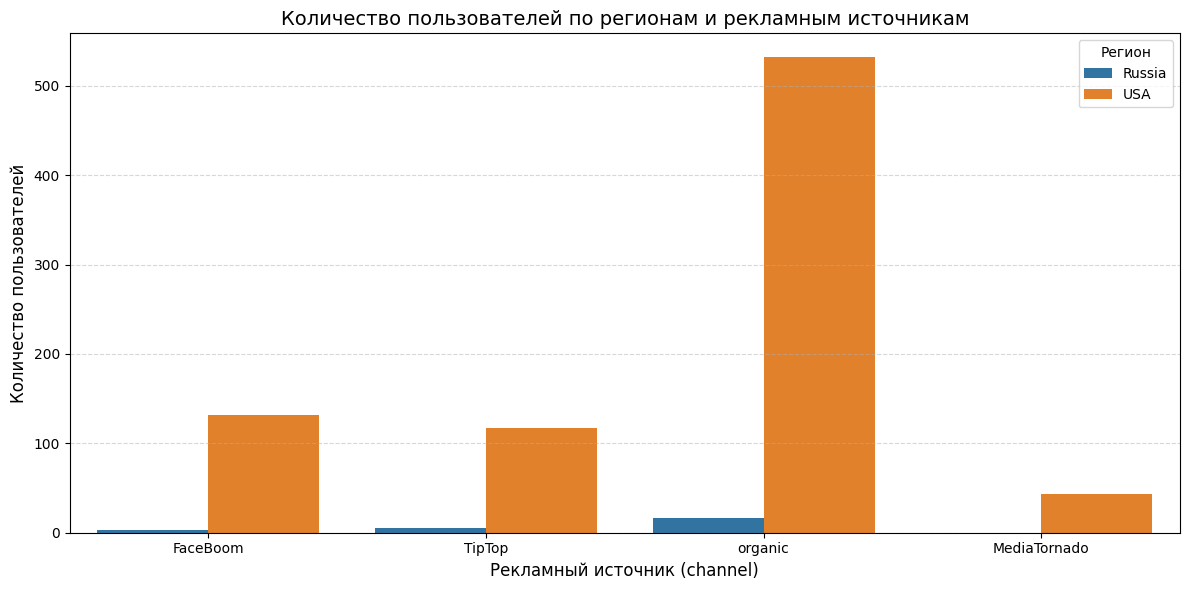

In [39]:
plt.figure(figsize=(12, 6))

# barplot с разделением по region
sns.barplot(data=pivot_q1, x='channel', y='count', hue='region')

plt.title('Количество пользователей по регионам и рекламным источникам', fontsize=14)
plt.xlabel('Рекламный источник (channel)', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.legend(title='Регион')
plt.grid(axis='y', linestyle='--', alpha=0.5)  # сетка по оси Y с пунктирными линиями
plt.tight_layout()
plt.show()

**Вывод:**

* В выборке видно, что наибольшее количество пользователей пришло из США, а не из России.
* Среди рекламных источников в США лидирует organic (532 пользователя), затем идут FaceBoom (132) и TipTop (117), что указывает на высокую эффективность органических каналов.
* В России также преобладает organic (16 пользователей), но общее количество пользователей существенно меньше, чем в США.
* Остальные каналы (FaceBoom, TipTop, MediaTornado) привлекают сравнительно меньше пользователей в обоих регионах.

#### Индивидуальное задание №2

Условие: Использовать pandas и plot. По сводной таблице (pivot_table) - отобразить уникальное (nunique) количество пользователей для каждого канала (channel). Оставить только маркеры в виде треугольника синего цвета размером 15.

values='user_id' — считаем уникальные значения пользователей.

index='channel' — группировка по рекламным источникам.

aggfunc='nunique' — подсчёт уникальных пользователей.

In [47]:
# Сводная таблица: уникальные пользователи для каждого канала
pivot_users = df_clean.pivot_table(values='user_id', index='channel', aggfunc='nunique')
display(pivot_users)

,user_id
channel,
FaceBoom,133
MediaTornado,44
TipTop,120
organic,491


Построение графика с маркерами

.plot() — метод pandas, который рисует график.

Параметры:

marker='^' — каждая точка обозначается треугольничком;

linestyle='' — линии между точками не проводятся (только отдельные маркеры);

color='blue' — цвет маркеров синий;

markersize=15 — размер маркеров;

ax=plt.gca() — строить график на текущих осях (это важно, чтобы можно было потом добавлять надписи на те же оси).

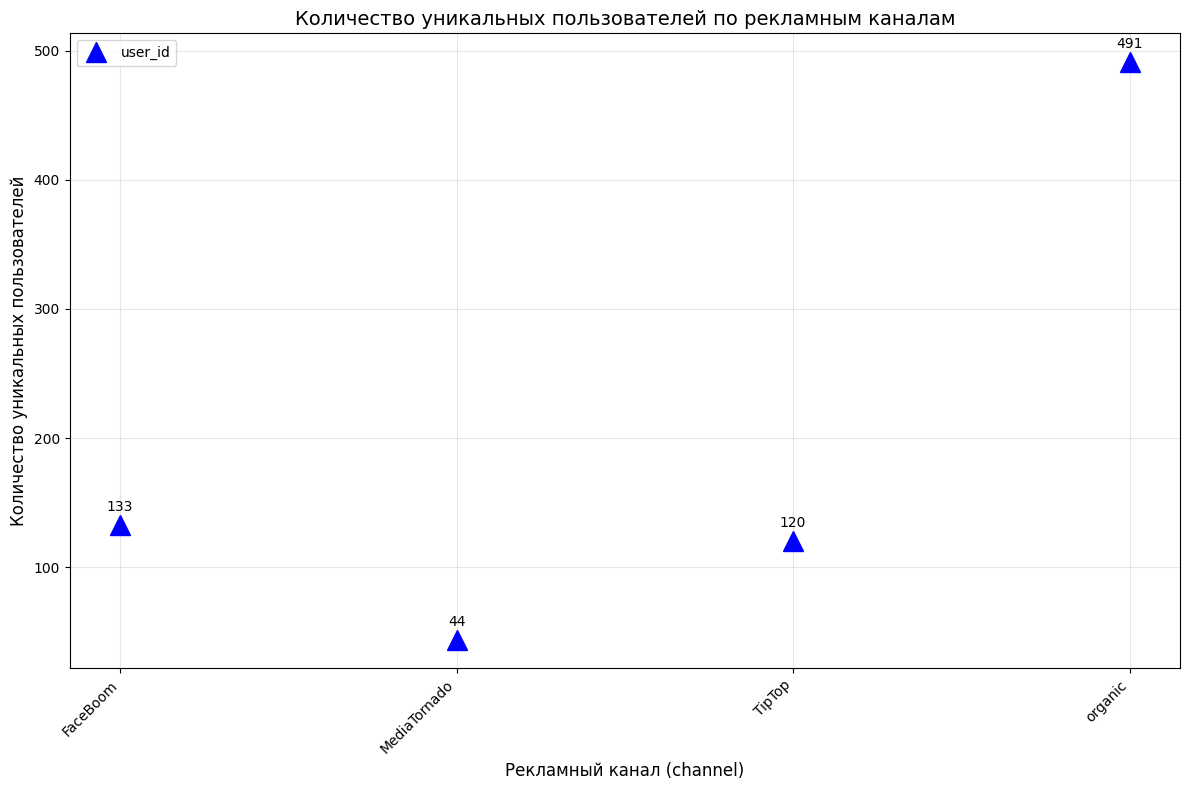

In [48]:
plt.figure(figsize=(12, 8))

# Синие треугольники, только маркеры, без линий
ax = pivot_users.plot(marker='^', linestyle='', color='blue', markersize=15, ax=plt.gca())

plt.title('Количество уникальных пользователей по рекламным каналам', fontsize=14)
plt.xlabel('Рекламный канал (channel)', fontsize=12)
plt.ylabel('Количество уникальных пользователей', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)

# Добавление числовых аннотаций над каждым маркером
for i, (channel, users) in enumerate(pivot_users['user_id'].items()):
    ax.annotate(f'{users}', (i, users), textcoords="offset points", xytext=(0,10), ha='center')

# Настройка подписей по оси X
ax.set_xticks(range(len(pivot_users.index)))
ax.set_xticklabels(pivot_users.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Вывод:**

На графике видно, что наибольшее количество уникальных пользователей привлечено через канал organic (491 пользователь), за ним следуют FaceBoom (133) и TipTop (120). Канал MediaTornado оказался наименее результативным (44 пользователя), что указывает на различную эффективность рекламных источников.

#### Индивидуальное задание №3 

Условие:  Использовать matplotlib. Построить круговую диаграмму, которая отображает процент каждого устройства (device)

Описание действий:

1. Подготовка данных

Сначала считаем количество записей для каждого типа устройства:

* value_counts() подсчитывает, сколько сессий зарегистрировано для каждого уникального устройства.
* Фильтрация убирает редкие категории (например, устройства с <5 сессий), чтобы диаграмма была читаемой.

In [49]:
# Подсчёт количества сессий для каждого устройства
device_counts = df_clean['device'].value_counts()

# Фильтрация: убираем устройства с очень маленьким количеством сессий, если нужно
device_q = device_counts[device_counts >= 5]  # оставляем только устройства с ≥5 сессиями

display(device_q)

device
iPhone     365
Mac        223
Android    173
PC          88
Name: count, dtype: int64

* plt.cm.Set3 — встроенная палитра пастельных цветов.
* range(len(device_q)) — создаёт столько цветов, сколько уникальных устройств.
* explode — смещает первый сектор, чтобы визуально выделить наиболее значимую категорию.
* labels=device_q.index — названия устройств.
* autopct='%1.1f%%' — отображение процентов в каждом секторе.
* startangle=90 — первый сектор сверху.
* colors=colors — уникальные цвета для каждого устройства.
* explode=explode — смещение первого сектора наружу.
* textprops — стиль текста (размер и жирность).
* pctdistance=0.85 — расстояние процентов от центра.
* Легенда: вынесена справа (bbox_to_anchor=(1.3, 1)), чтобы не перекрывать диаграмму.

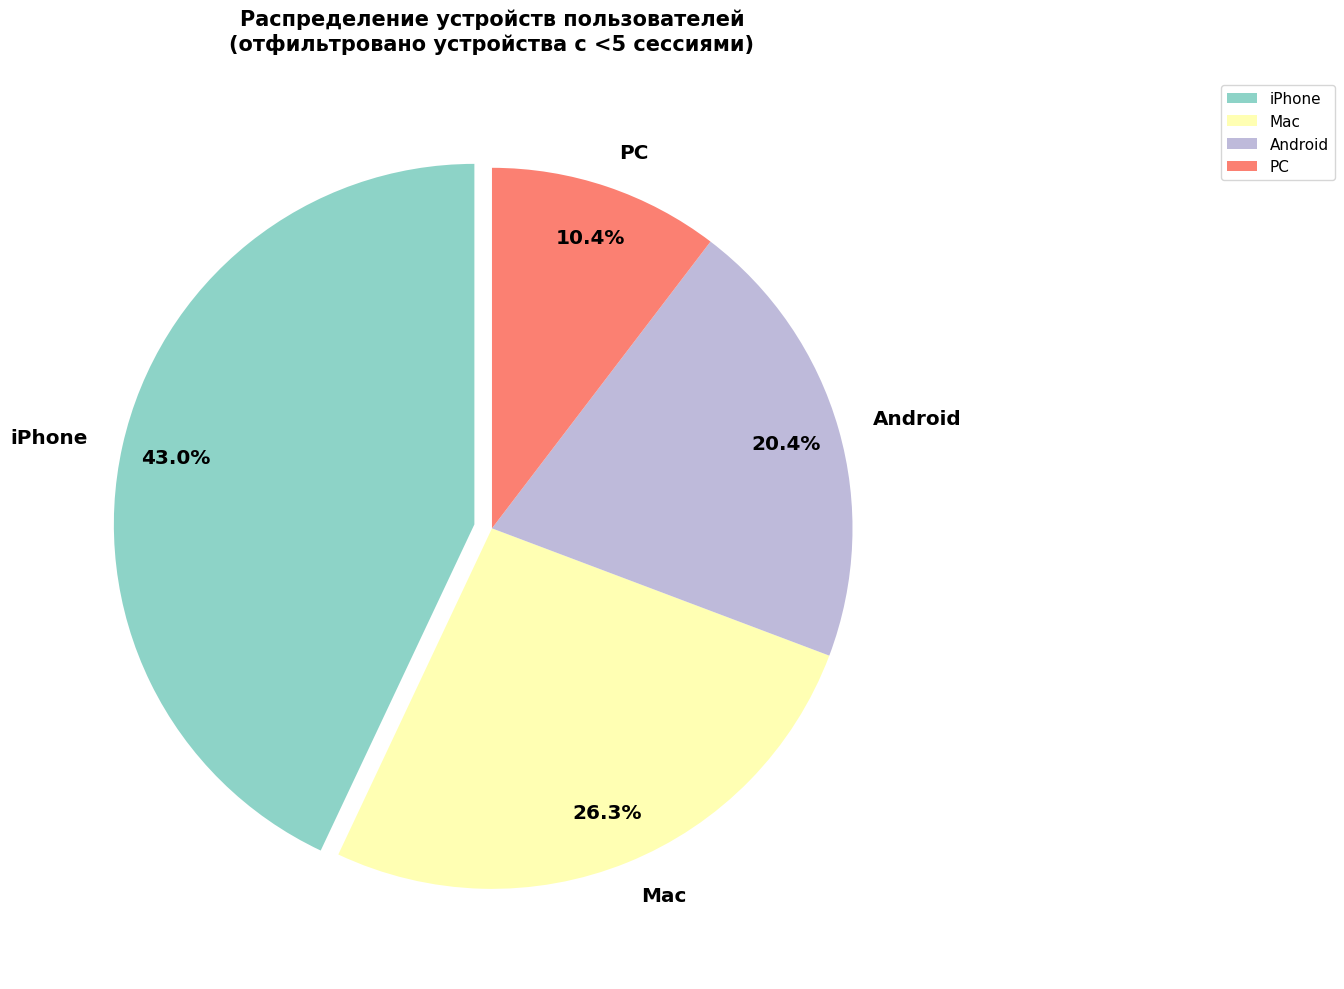

In [50]:
# Цвета: Set3 — гармоничная палитра Matplotlib
colors = plt.cm.Set3(range(len(device_q)))

# "Вытяжка" сектора: смещаем немного первый сектор для выделения
explode = [0.05 if i == 0 else 0 for i in range(len(device_q))]

plt.figure(figsize=(14, 10))

plt.pie(device_q,
        labels=device_q.index,      # подписи с типами устройств
        autopct='%1.1f%%',          # процент внутри сектора с одним знаком после запятой
        startangle=90,               # первый сектор начинается сверху (12 часов)
        colors=colors,               # цвет каждого сектора
        explode=explode,             # смещение выделенного сектора
        textprops={'size': 'x-large', 'weight': 'bold'},  # стиль подписей
        pctdistance=0.85)            # положение процентов внутри сектора

plt.title('Распределение устройств пользователей\n(отфильтровано устройства с <5 сессиями)',
          fontsize=15, pad=20, weight='bold')

# Легенда справа
plt.legend(device_q.index,
           fontsize=11,
           bbox_to_anchor=(1.3, 1),
           loc='upper left')

plt.tight_layout()
plt.show()

**Вывод:**

На круговой диаграмме видно, что большинство пользователей используют устройства iPhone (365 сессий), за ними следуют Mac (223) и Android (173). Наименее популярны ПК (88 сессий), что указывает на преимущественное использование мобильных устройств для посещения магазина.

#### График типа Hexagonal Binning Plot

Формулировка задания: Построить минимум один график типа hexbin для визуализации плотности распределения данных и сделать выводы о взаимосвязях между признаками. 
Такой график особенно удобен, когда данных много, и обычный scatter-plot превращается в плотное облако точек.

Описание процесса

1. Создаётся фигура fig и система координат ax размером 12×8 дюймов с помощью plt.subplots().

2. Функция ax.hexbin() строит шестиугольную диаграмму плотности, где каждая ячейка показывает количество точек (наблюдений), попавших внутрь.

3. Основные параметры:

* df_clean['time_session'] — значения по оси X (время сессии).

* df_clean['price'] — значения по оси Y (стоимость покупок).

* gridsize=25 — количество шестиугольников вдоль одной оси; чем больше, тем более детальная сетка.

* cmap='Greens' — цветовая схема; более тёмные оттенки показывают зоны с большим количеством наблюдений.

* mincnt=1 — отображаются только ячейки с хотя бы одним наблюдением.

4. Добавляется цветовая шкала colorbar, поясняющая количество точек в каждой ячейке.

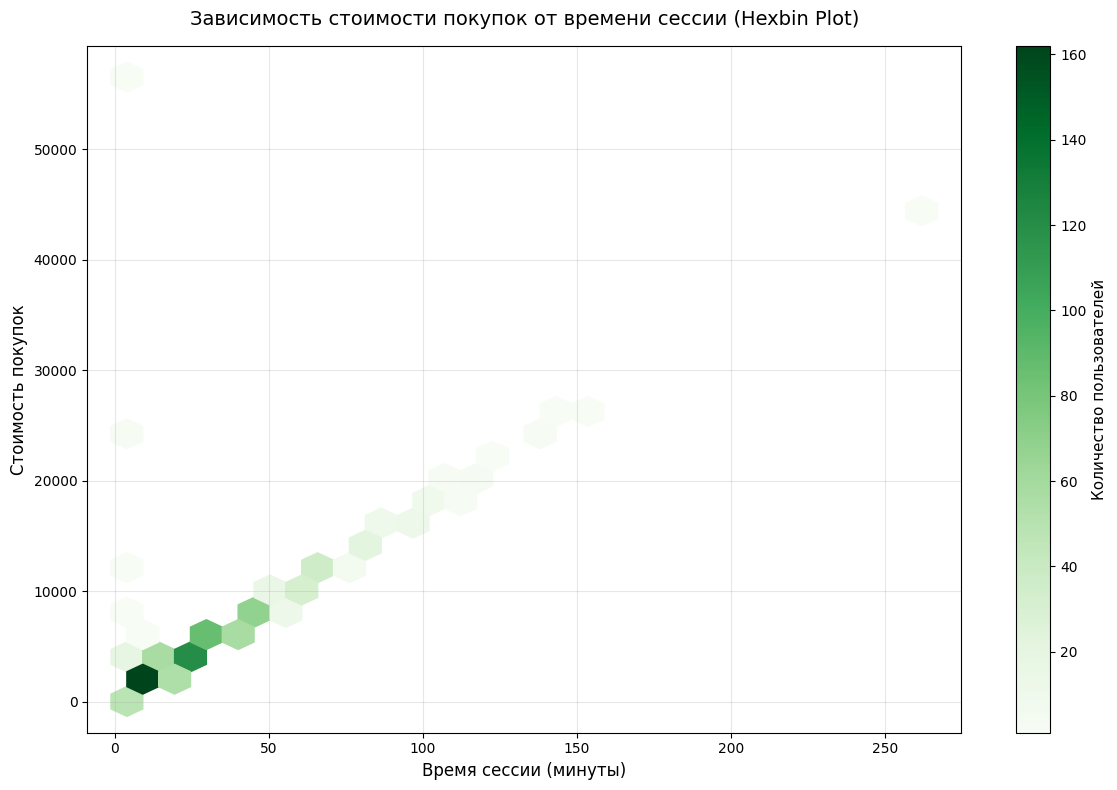

In [32]:
fig, ax = plt.subplots(figsize=(12, 8))

hexbin = ax.hexbin(df_clean['time_session'],
                   df_clean['price'],
                   gridsize=25,
                   cmap='Greens',
                   mincnt=1)

ax.set_xlabel('Время сессии (минуты)', fontsize=12)
ax.set_ylabel('Стоимость покупок', fontsize=12)
ax.set_title('Зависимость стоимости покупок от времени сессии (Hexbin Plot)', fontsize=14, pad=15)
ax.grid(True, alpha=0.3)

cb = plt.colorbar(hexbin, ax=ax)
cb.set_label('Количество пользователей', fontsize=11)

plt.tight_layout()
plt.show()

**Вывод:**
График шестигранной плотности (Hexbin Plot) наглядно демонстрирует взаимосвязь между двумя ключевыми метриками — продолжительностью сессии и суммой потраченных средств.

Ключевые наблюдения:
1. Концентрация данных (ядро пользовательской активности):

Основная масса пользовательских сессий крайне короткая и не приводит к покупкам. Самая высокая плотность (наиболее яркие шестиугольники) наблюдается в области, где время сессии стремится к 0-10 минутам, а стоимость покупок равна 0. Это визуально подтверждает вывод, сделанный из гистограмм: большинство сессий являются "холодными" и не конвертируются в продажи.

2. Явная положительная зависимость:

На графике четко прослеживается положительная корреляция между временем, проведенным на сайте, и стоимостью совершенных покупок. Это проявляется в виде "шлейфа" из шестиугольников, тянущегося из области низких значений вправо и вверх.

По мере увеличения длительности сессии (движение вправо по оси X) средняя стоимость покупки (положение по оси Y) имеет явную тенденцию к росту.

3. Характер распределения "шлейфа":

Шлейф данных не является сплошным и однородным. Он состоит из отдельных "кластеров" или "точек концентрации". Например, можно выделить группу сессий длительностью ~25 минут со стоимостью около 4500, группу сессий длительностью ~60-80 минут со стоимостью около 11000-15000, и редкие выбросы с очень высокой стоимостью (>30000) при большом времени сессии (>150 минут).

Это позволяет выдвинуть гипотезу о существовании определенных "паттернов покупок". Разные кластеры могут соответствовать разным типам покупательского поведения: быстрая покупка одного товара, тщательное сравнение нескольких товаров средней ценовой категории, формирование крупного заказа.

4. Редкие (аномальные) события:

Сессии, длящиеся более 150 минут и приводящие к покупкам на суммы свыше 30000, являются исключительными случаями (представлены самыми темными и единичными шестиугольниками). Это могут быть либо корпоративные заказы, либо покупки очень дорогостоящих товаров (например, электроники или ювелирных изделий).

#### Диаграммы размаха (Boxplot)

Формулировка задания: Выполните минимум один график типа boxplot для любого столбца. Сделайте выводы.

##### Базовый Boxplot для стоимости поездки

* Анализируем столбец price — стоимость покупок пользователей.
* Boxplot показывает медиану, нижний и верхний квартиль, а также выбросы.
* vert=False — горизонтальный boxplot.
* widths=0.5 — задаёт высоту ящика.
* patch_artist=True — позволяет раскрасить ящик.
* boxprops — цвет и прозрачность заливки ящика.
* medianprops — цвет и толщина линии медианы.
* whiskerprops и capprops — оформление усов и их “крышечек”.
* plt.grid(axis='x', alpha=0.3) — сетка по оси X для удобства чтения.

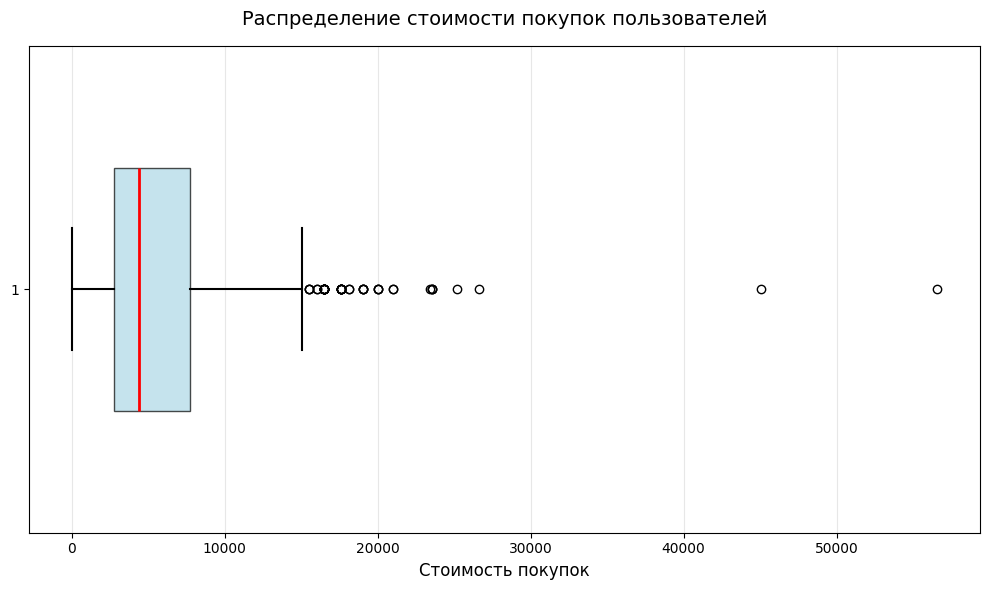

In [51]:
plt.figure(figsize=(10, 6))

box = plt.boxplot(df_clean['price'],
                  vert=False,                # горизонтальный ящик
                  widths=0.5,                # толщина ящика
                  patch_artist=True,          # разрешает раскрашивать ящик
                  boxprops=dict(facecolor='lightblue', alpha=0.7),  # заливка голубая, прозрачность 0.7
                  medianprops=dict(color='red', linewidth=2),       # медиана красная, толщина 2
                  whiskerprops=dict(color='black', linewidth=1.5),  # “усы” чёрные
                  capprops=dict(color='black', linewidth=1.5))      # крышечки на концах усов

plt.xlabel('Стоимость покупок', fontsize=12)
plt.title('Распределение стоимости покупок пользователей', fontsize=14, pad=15)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод:**

График "ящик с усами" наглядно демонстрирует ключевые статистические характеристики распределения суммы, которую пользователи тратят за одну сессию.

Ключевые наблюдения:
1. Положение медианы (центральная тенденция):

* Медиана (линия внутри ящика) расположена на отметке 0. Это означает, что как минимум 50% всех пользовательских сессий не заканчиваются совершением какой-либо покупки. Данный факт полностью согласуется с предыдущими анализами, где мы видели огромный столбец на 0 в гистограмме распределения покупок.

2. Расположение и размер ящика (межквартильный размах - IQR):

* Сам "ящик" (который охватывает 50% центральных данных, между 1-м и 3-м квартилями) очень узкий и прижат к нулю. Это говорит о том, что среди тех сессий, где покупки все же совершались, бóльшая часть приходится на заказы с относительно невысокой и компактно распределенной стоимостью.

3. Наличие и масштаб выбросов:

* График демонстрирует огромное количество выбросов, которые визуализируются точками, расположенными далеко за "усами". "Усы" на подобных графиках обычно заканчиваются на значениях Q3 + 1.5*IQR, и все точки beyond этого предела считаются выбросами.
* В нашем случае эти выбросы — это сессии с исключительно высокой стоимостью покупок, достигающей 40,000 - 50,000. При этом важно помнить, что эти "выбросы" с точки зрения бизнеса являются наиболее ценными клиентами, формирующими значительную долю выручки.

##### Создание категорий по цене и Boxplot по новым категориям

Формулировка задания: Добавьте категорию по любому числовому столбцу. Сделайте boxplot по этому числовому столбцу по каждой новой категории.

* quantile(0.33) и quantile(0.67) делят данные на три равные части по количеству наблюдений.
* df_clean['price'].max() + 1 гарантирует, что все значения включены в последний интервал.
* В результате стоимость делится на категории: низкая, средняя, высокая.
* pd.cut() “разрезает” числовой столбец на интервалы и создаёт новый категориальный столбец.
* labels=price_labels — названия категорий.
* include_lowest=True — минимальные значения точно попадают в первый интервал.

In [52]:
## ОПРЕДЕЛЕНИЕ ГРАНИЦ ИНТЕРВАЛОВ
price_bins = [
    0,  # минимальная граница (самые дешёвые покупки)
    df_clean['price'].quantile(0.33),  # 33-й перцентиль — граница между низкой и средней ценой
    df_clean['price'].quantile(0.67),  # 67-й перцентиль — граница между средней и высокой ценой
    df_clean['price'].max() + 1        # верхняя граница чуть больше максимального значения
]

price_labels = ['Низкая', 'Средняя', 'Высокая']

## СОЗДАНИЕ СТОЛБЦА КАТЕГОРИИ
df_clean['price_category'] = pd.cut(
    df_clean['price'],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True  # минимальные значения попадут в первый интервал
)

# Проверка количества наблюдений в каждой категории
df_clean['price_category'].value_counts().sort_index()

price_category
Низкая     286
Средняя    291
Высокая    272
Name: count, dtype: int64

Выбор данных: 
* x='price_category' — по оси X будут категории стоимости: низкая, средняя, высокая.
* y='time_session' — по оси Y отображаются числовые значения времени сессий.

График показывает: 
* Медиана — центральная линия внутри ящика (красная или чёрная).
* Ящик — диапазон между 25-м и 75-м процентилями (Q1 и Q3).
* “Усы” — линии, показывающие диапазон типичных значений (обычно до 1.5 IQR от квартилей).
* Выбросы — отдельные точки, лежащие за пределами усов, показывающие экстремальные значения.

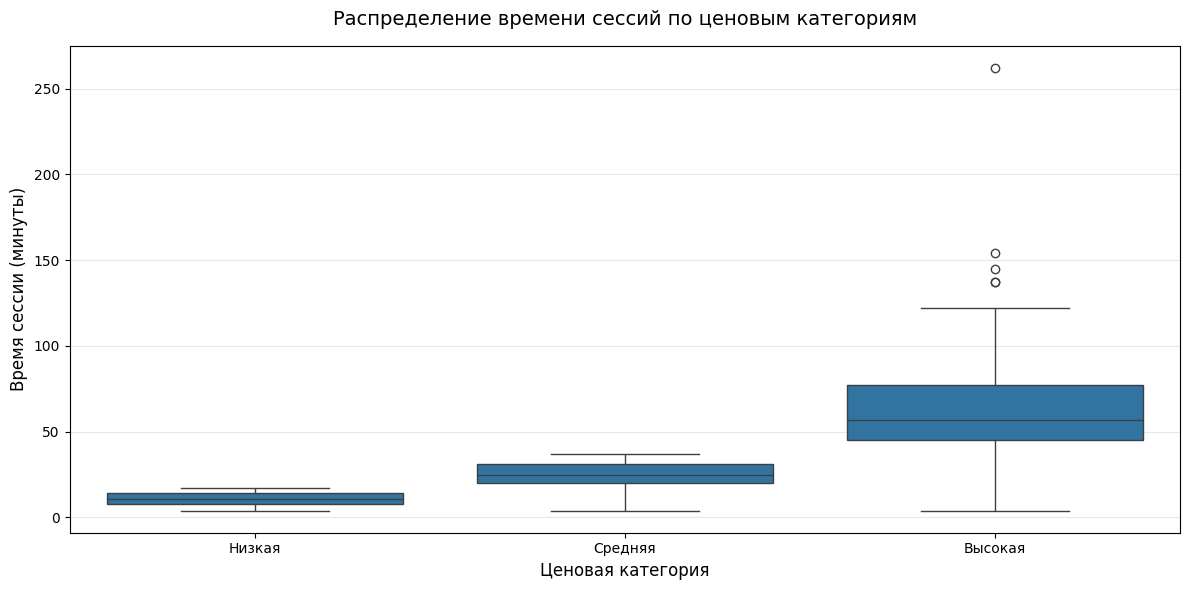

In [53]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df_clean, x='price_category', y='time_session')

plt.xlabel('Ценовая категория', fontsize=12)
plt.ylabel('Время сессии (минуты)', fontsize=12)
plt.title('Распределение времени сессий по ценовым категориям', fontsize=14, pad=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод:**

График наглядно демонстрирует взаимосвязь между ценовой категорией покупки и продолжительностью пользовательской сессии, позволяя сделать важные выводы о поведении разных сегментов клиентов.

1. Явная положительная зависимость:

* Наблюдается четкий восходящий тренд: медианное время сессии последовательно увеличивается от категории "Низкая" к категории "Высокая". Это визуальное подтверждение гипотезы, выдвинутой при анализе графика Hexbin: чем дольше пользователь взаимодействует с сайтом, тем более дорогую покупку он в среднем совершает.

2. Характеристики по категориям:

* Низкая ценовая категория: Медиана времени сессии находится на относительно низком уровне. "Ящик" (межквартильный размах) компактный, что говорит о том, что большинство сессий, заканчивающихся недорогими покупками, длятся недолго и имеют схожую продолжительность. Это могут быть быстрые, целевые покупки.
* Средняя ценовая категория: Медиана времени сессии заметно выше, чем в низкой категории. Разброс данных (высота "ящика" и "усов") также увеличивается, что указывает на большее разнообразие в поведении пользователей.
* Высокая ценовая категория: Медиана времени сессии является наибольшей. При этом часто наблюдается самый широкий разброс данных — "ящик" высокий, а "усы" длинные. Это означает, что для совершения дорогих покупок пользователям в среднем действительно требуется больше времени, но продолжительность этих сессий может сильно варьироваться: от достаточно продолжительных до очень долгих.

3. Наличие выбросов:

* Во всех категориях, но особенно в средней и высокой, присутствуют выбросы — сессии, время которых значительно превышает типичное. Это подчеркивает, что не существует жесткого временного порога для совершения покупки определенной категории: некоторые пользователи могут долго и мучительно выбирать недорогой товар, в то время как другие могут быстро совершить дорогостоящую покупку.

##### Boxplot по другим категориям

Формулировка: Выполните ещё минимум 2 графика boxplot по другим категориям (например, зарплата по полу, зарплата по должности и т.п. - в результате несколько box-ов длякаждой категории на ном графике). Используйте для построения графиков разныебиблиотеки (минимум 2). Сделайте вывод.

1. **Boxplot 1: Время сессии по устройству (Seaborn)**

Описание : необходимо построить график boxplot для столбца time_session по категориям device. Каждое устройство будет представлено отдельным ящиком, показывающим распределение времени сессий пользователей на этом устройстве.

* x='device' — категории по устройству (iPhone, Mac, Android, PC).
* y='time_session' — числовой признак (время сессии).
* sns.boxplot() строит несколько ящиков для каждой категории.

Описание графика: 

* Каждый ящик отображает медиану, квартильные границы, усы и выбросы для пользователей конкретного устройства.
* Легко сравнить, на каких устройствах сессии были длиннее или короче.

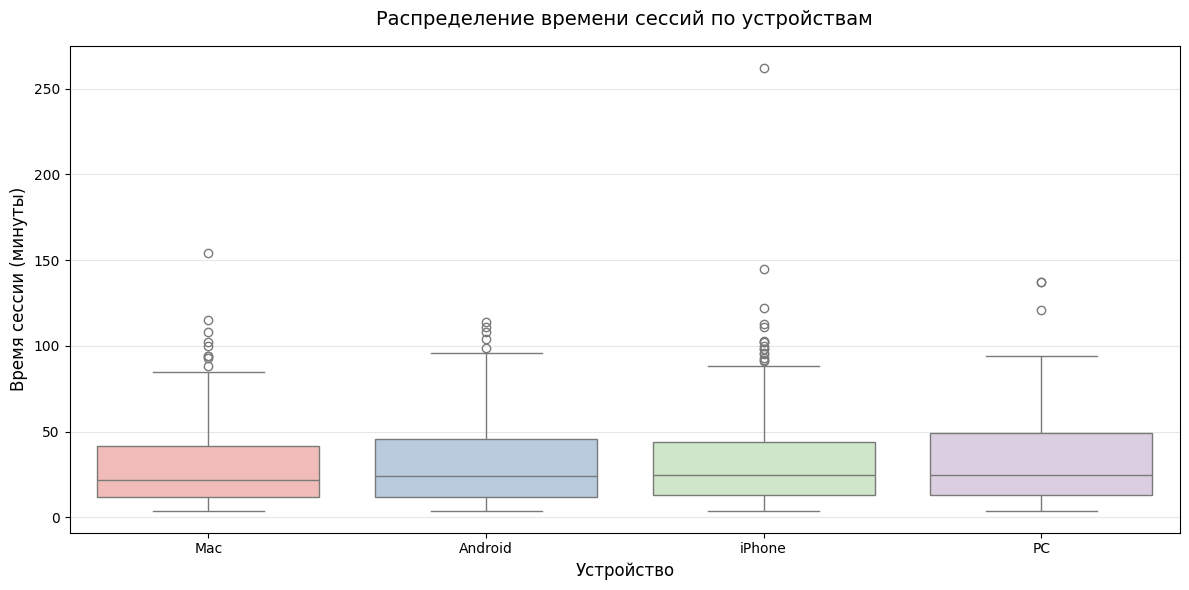

In [61]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean, x='device', y='time_session', hue='device', palette='Pastel1')


plt.xlabel('Устройство', fontsize=12)
plt.ylabel('Время сессии (минуты)', fontsize=12)
plt.title('Распределение времени сессий по устройствам', fontsize=14, pad=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод:**

График наглядно показывает различия в поведении пользователей в зависимости от типа устройства.

Ключевые наблюдения:
* Медианы для всех типов устройств смещены к нижней границе, что указывает на асимметричное распределение времени сессии. Среднее время сессии примерно одинаковое для всех устройств, за исключением пользователей Mac, у которых сессии короче.
* Размер ящиков показывает, что наибольший разброс типичных значений времени сессии наблюдается у PC, тогда как остальные устройства демонстрируют сопоставимую стабильность.
* Все устройства имеют выбросы, но у PC время сессии варьируется сильнее, из-за чего количество явных выбросов кажется меньше.

2. **Стоимость покупок по рекламным каналам (Matplotlib)**

Описание: использование библиотеки Matplotlib для построения boxplot столбца price по категориям channel. На одном графике будут показаны ящики для всех рекламных источников, что позволяет визуально сравнить, через какой канал приходят более дорогие покупки.

* df_clean['channel'].unique() — список категорий (FaceBoom, MediaTornado, TipTop, organic).
* plt.boxplot() строит ящики для каждой категории отдельно.

Описание графика: 

* Каждый ящик визуализирует медиану, квартильные границы, усы и выбросы стоимости покупок для конкретного канала.
* Позволяет быстро оценить, через какие каналы приходят более дорогие покупки и где наблюдаются экстремальные значения.

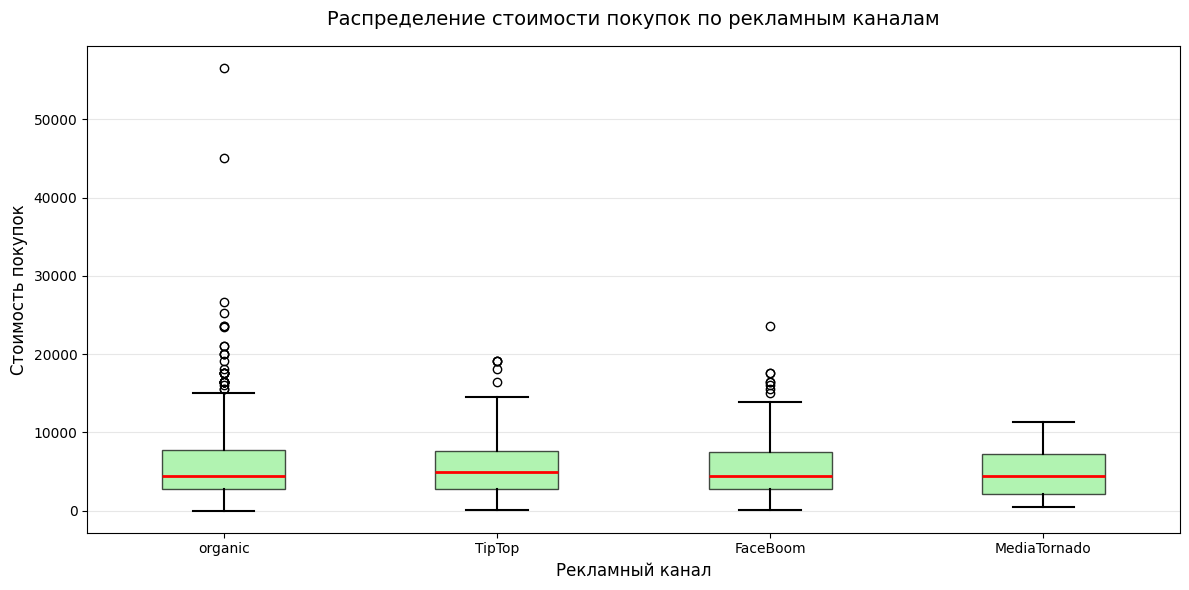

In [59]:
channels = df_clean['channel'].unique()
data_to_plot = [df_clean[df_clean['channel'] == ch]['price'] for ch in channels]

plt.figure(figsize=(12, 6))
plt.boxplot(data_to_plot,
            tick_labels=channels,
            patch_artist=True,
            boxprops=dict(facecolor='lightgreen', alpha=0.7),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5))

plt.xlabel('Рекламный канал', fontsize=12)
plt.ylabel('Стоимость покупок', fontsize=12)
plt.title('Распределение стоимости покупок по рекламным каналам', fontsize=14, pad=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод:**

График наглядно показывает распределение стоимости покупок по рекламным каналам.

Ключевые наблюдения:
* Медианы на каналах organic и FaceBoom смещены относительно центра ящика, что указывает на асимметричное распределение стоимости. Для каналов MediaTornado и TipTop распределение ближе к симметричному.
* Размер ящиков примерно одинаковый, что говорит о сопоставимом разбросе типичных значений стоимости на всех каналах.
* Наибольшее количество выбросов наблюдается на канале organic, остальные каналы демонстрируют более стабильное распределение стоимости.

### Вывод о лабораторной работе

В ходе лабораторной работы был проведён анализ данных пользовательских сессий магазина. Данные были предварительно очищены от пропусков, дубликатов и аномалий, что позволило получить корректный и готовый к анализу датасет.

Анализ корреляций и ковариаций показал, что стоимость покупок (price) положительно связана с количеством кликов и временем сессии, тогда как возраст пользователей и идентификатор пользователя коррелируют слабо. Это подтверждает, что ключевыми факторами стоимости являются активность и длительность сессии.

График hexagonal binning plot продемонстрировал, что максимальная плотность наблюдений приходится на короткие сессии с относительно низкой стоимостью покупок, что отражает типичное поведение пользователей.

Анализ по категориям выявил, что наибольшее число пользователей привлекают каналы organic и FaceBoom, а распределение по устройствам показывает, что iPhone используется чаще всего, тогда как PC встречается реже.

Boxplot-анализ подтвердил закономерности распределения: медианы и размеры ящиков показали асимметричное распределение стоимости и времени сессий по каналам и устройствам, при этом наибольшее число выбросов наблюдается для канала organic и устройства PC.

Таким образом, проведённый анализ позволил выявить ключевые закономерности в поведении пользователей, оценить стабильность временных сессий и стоимости покупок, а также визуально оценить распределение данных по категориям. Использование инструментов визуализации (Matplotlib, Seaborn, Pandas) показало их эффективность для интерпретации взаимосвязей и структуры данных.

### Дополнительное задание

**`Подробная формулировка задания`**

In [24]:
# код выполнения задания

***`Подробный вывод по заданию, описание полученных результатов`***